# **Clustering Evaluation Metrics**
### **1. Why We Need Clustering Metrics**

In supervised learning, model quality is easy to measure because we compare predictions against known labels. In clustering, however, no such labels exist, so we must evaluate the structure of the clusters themselves rather than correctness against a target. This creates a unique challenge: a clustering solution can “look” mathematically valid yet still be meaningless for the problem context.

Because of this, a good clustering evaluation metric must capture three fundamental properties of a well-formed cluster:

* Compactness – points inside a cluster should be as close to each other as possible.
* Separation – different clusters should be as far apart from each other as possible.
* Stability – small perturbations in data should not drastically change the structure.

These three ideas form the theoretical basis for most internal clustering metrics.

---

### **2. Types of Clustering Metrics**

Clustering metrics are generally divided into internal and external categories:

* Internal metrics evaluate the quality of the clustering structure using only the features and the resulting cluster assignments. These are the most commonly used metrics in real-world situations where no ground truth labels exist.
* External metrics evaluate how well the clustering aligns with known labels or categories. They are used mainly for academic comparisons or benchmarking because true labels are rarely available in practice.

| Type     | Description | When Used | Examples |
| -------- | ----------- | ----------| -------- |
| Internal | Measure cluster structure (compactness + separation) | Real-world tasks without labels | Silhouette, Calinski-Harabasz, Davies-Bouldin |
| External | Compare predicted clusters with real labels          | Benchmark / validation datasets | ARI, NMI, Purity                         |

---


### **3. Internal Evaluation Metrics – Deeper Explanation**
#### **3.1 Silhouette Score (Balanced Compactness + Separation)**

The silhouette score is one of the most widely used clustering evaluation metrics because it captures both how similar a point is to its own cluster (compactness) and how dissimilar it is from other clusters (separation). For each point, the algorithm computes:

* a(i): the average distance to all other points within the same cluster (lower = more compact)
* b(i): the average distance to the closest neighboring cluster (higher = more separated)

<center>
$s(i) = \frac{b(i) - a(i)}{max(a(i), b(i))}$
</center>

The resulting value ranges from -1 to 1. A score close to 1 indicates that the sample is well placed inside its cluster and far from others. A value near 0 suggests boundary ambiguity, while negative values imply likely misclassification. This makes silhouette particularly helpful for selecting the optimal number of clusters (k) in K-Means.

#### **3.2 Calinski–Harabasz Index (Global Cluster Dispersion)**

The Calinski–Harabasz index compares the variance between clusters (how far apart their centroids are) to the variance within clusters (how tightly points are grouped around their centroids). Higher values indicate that clusters are dense internally but well separated from each other.

<center>
$CH = \frac{tr(B_k)}{tr(W_k)} x \frac{n_E - k}{k - 1}$
</center>

where tr(Bk) is trace of the between group dispersion matrix and tr(Wk) is the trace of the within-cluster dispersion matrix.

This metric effectively rewards clustering solutions with compact and well-isolated groups, which aligns perfectly with the geometric assumptions of K-Means (spherical, convex clusters). It is also computationally efficient, making it suitable for tuning models on large datasets.

#### **3.3 Davies–Bouldin Index (Penalty for Overlapping Clusters)**

Unlike CH, the Davies–Bouldin index emphasizes the worst-performing cluster pairs. For every pair of clusters, it examines the ratio between the sum of their internal scatter and the distance between their centroids. If two clusters are too close together or have wide internal spread, this ratio increases, worsening the score.

<center>
$DB = \frac{1}{k} \sum_{i=1}^{k}\max_{j\not=i}\frac{S_i + S_j}{M_ij}$
</center>

Where:

* S_i = avg distance of all points in cluster i to its centroid (scatter)
* M_ij = distance between centroids of cluster i and j (separation)

Since it focuses on the most problematic cluster pair, the DB index provides a more conservative evaluation than CH. Lower values indicate better clustering performance. This metric is particularly insightful when clusters vary in size or shape, or when some clusters are far more condensed than others.

---

### **4. External Metrics – Only When Ground Truth Exists**

In some rare cases — typically benchmark or labeled datasets — we have access to the true class labels. External metrics compare how well the unsupervised clustering reproduces this ground truth.

| Metric     | Description  | Best Usage |
| ---------- | ------------ |------------ |
| **ARI**    | Measures pairwise agreement: if two samples are in the same cluster in ground truth and predicted clustering | Most robust external metric |
| **NMI**    | Measures how much *information* about the true distribution is preserved by the predicted clusters           | Good for unbalanced clusters |
| **Purity** | Measures the dominant class frequency inside each predicted cluster                                          | Simple but greedy            |



External metrics are excellent for validation studies and algorithm comparison but are not applicable in most practical clustering tasks.

---

### **5. Why K-Means Often Scores High on These Metrics**

Many internal metrics implicitly assume spherical, equally sized, and convex clusters, which are the exact type of clusters K-Means is designed to produce. It optimizes Euclidean distance to a centroid, which aligns naturally with metrics like Silhouette, CH, and DB. As a result, K-Means tends to outperform algorithms like DBSCAN or Spectral Clustering on these metrics, even when it is not the best conceptual model for the actual data structure.

### **6. When These Metrics Fail**
| Scenario                            | Failure                               | Better Algorithm         |
| ----------------------------------- | ------------------------------------- | ------------------------ |
| Non-spherical / elliptical clusters | Silhouette gives misleading results   | GMM, Spectral Clustering |
| Varying density                     | CH incorrectly boosts score           | DBSCAN / HDBSCAN         |
| Noise / outliers                    | CH, silhouette degrade heavily        | DBSCAN                   |
| Imbalanced cluster size             | Silhouette penalizes smaller clusters | GMM                      |

### **7. Summary**
Clustering evaluation is fundamentally different from supervised model evaluation because there are no labels to compare against. For this reason, the goal of evaluation shifts from measuring predictive accuracy to assessing the quality and structure of the cluster formation itself. A good clustering metric must confirm that clusters are internally compact, externally well-separated, and stable under small perturbations.

Internal metrics such as Silhouette, Calinski–Harabasz, and Davies–Bouldin are the most widely used in real-world applications, since ground truth labels are rarely available. Each of these metrics reflects a slightly different perspective: Silhouette balances sample-level compactness and separation, CH emphasizes global separation vs. internal variance, and DB penalizes closely overlapping or poorly separated clusters. External metrics like ARI, NMI, and Purity are useful only when true class labels exist, typically in benchmarking or academic validation scenarios.

Because most of these internal metrics are built around concepts of spherical, isotropic separation, algorithms such as K-Means tend to score highly, even if the dataset would be better modeled by non-convex or density-based clustering methods. As a result, evaluating a clustering model effectively requires not only reading the metric scores but also understanding the assumptions and limitations behind them. In practice, this means metric selection should be guided by the shape, density, noise profile, and balance of the clusters, rather than by numeric score alone.

### **Import**

In [10]:
import pandas as pd
pd.options.display.float_format = '{:,.2f}'.format
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans, AgglomerativeClustering
import pickle


from sklearn.cluster import KMeans, AffinityPropagation, MeanShift, estimate_bandwidth, OPTICS, DBSCAN
from itertools import product

In [11]:
df = pd.read_csv("/content/drive/MyDrive/YL_Dersler/Python/Ödev/Codes/data_processed.csv")
df

,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Customer_Tenure,Recency_Group,Tenure_Group,Total_Kids,Total_Spending,Total_Accepted_Cmp,Total_Num_Purchases,Income_Cat
0,-0.35,0.26,0.28,-0.83,-0.93,0.31,0.98,1.55,1.70,2.46,1.47,0.85,0.37,1.45,2.62,-0.55,0.70,-0.28,-0.29,-0.28,-0.26,-0.11,-0.10,2.36,0.99,1.54,-1.34,0.45,-1.28,1.68,-0.44,1.32,-1.33
1,-0.35,0.26,-0.27,1.03,0.90,-0.38,-0.87,-0.63,-0.72,-0.65,-0.63,-0.73,-0.17,-1.14,-0.58,-1.16,-0.13,-0.28,-0.29,-0.28,-0.26,-0.11,-0.10,-0.42,1.24,-1.18,-0.45,1.34,1.40,-0.96,-0.44,-1.16,0.41
2,-0.35,1.19,0.90,-0.83,-0.93,-0.79,0.36,0.57,-0.18,1.35,-0.15,-0.04,-0.72,1.45,-0.23,1.31,-0.55,-0.28,-0.29,-0.28,-0.26,-0.11,-0.10,-0.42,0.32,-0.20,-0.45,-0.45,-1.28,0.28,-0.44,0.80,1.29
3,-0.35,1.19,-1.18,1.03,-0.93,-0.79,-0.87,-0.56,-0.66,-0.50,-0.58,-0.75,-0.17,-0.77,-0.94,-0.55,0.29,-0.28,-0.29,-0.28,-0.26,-0.11,-0.10,-0.42,-1.28,-1.06,-0.45,1.34,0.06,-0.92,-0.44,-0.90,-0.46
4,1.42,-0.67,0.29,1.03,-0.93,1.55,-0.39,0.42,-0.22,0.16,-0.00,-0.56,1.45,0.34,0.13,0.07,-0.13,-0.28,-0.29,-0.28,-0.26,-0.11,-0.10,-0.42,-1.02,-0.95,0.44,1.34,0.06,-0.31,-0.44,0.54,-1.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2053,-0.35,1.19,5.15,1.03,-0.93,-0.90,-0.88,-0.31,-0.67,-0.54,-0.63,-0.61,0.91,-0.40,-0.58,-0.86,0.29,-0.28,-0.29,-0.28,-0.26,-0.11,-0.10,-0.42,-0.69,0.20,1.33,-1.34,0.06,-0.90,-0.44,-0.51,1.29
2054,-0.35,-0.67,0.42,-0.83,0.90,-0.10,1.20,0.42,0.07,0.09,2.19,3.91,-0.17,1.82,0.13,-0.55,-0.13,-0.28,-0.29,-0.28,-0.26,-0.11,-0.10,-0.42,0.15,0.14,-0.45,-1.34,0.06,1.22,-0.44,0.41,-1.33
2055,-0.35,-1.60,0.23,-0.83,-0.93,1.45,1.80,0.55,0.23,-0.10,-0.36,-0.38,-0.72,-0.77,0.13,2.23,0.29,-0.28,3.47,-0.28,-0.26,-0.11,-0.10,-0.42,-1.02,-0.98,0.44,1.34,-1.28,1.05,1.03,0.54,-1.33
2056,0.54,1.19,0.79,-0.83,0.90,-1.41,0.37,0.09,0.21,0.78,0.07,0.33,-0.17,0.71,0.84,1.31,-0.96,-0.28,-0.29,-0.28,-0.26,-0.11,-0.10,-0.42,1.07,-0.97,1.33,1.34,0.06,0.39,-0.44,1.06,1.29


In [12]:
with open('/content/drive/MyDrive/YL_Dersler/Python/Ödev/Codes/scaler.pkl','rb') as f:
    scaler = pickle.load(f)

with open('/content/drive/MyDrive/YL_Dersler/Python/Ödev/Codes/label_enc.pkl','rb') as f:
    le = pickle.load(f)

In [13]:
df_org = pd.DataFrame(scaler.inverse_transform(df), columns=df.columns)

In [14]:
to_encode = ['Tenure_Group', 'Recency_Group', 'Education', 'Marital_Status',
             'Income_Cat', 'Kidhome', 'Teenhome', 'AcceptedCmp3',
             'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
             'Complain', 'Response', 'Total_Kids', 'Total_Accepted_Cmp']


for col in to_encode:
  df_org[col] = le[col].inverse_transform(df_org[col].astype(int))

### **Helpers**

In [15]:
def plot_elbow_curve(df, model, min_clusters=2, max_clusters=10):
    """
    Plots the Elbow Curve to help determine the optimal number of clusters for models
    that require a predefined 'k' (number of clusters).

    Parameters:
    - df: pandas DataFrame or array-like, the data to cluster
    - model: clustering model instance (e.g., KMeans, AgglomerativeClustering)
    - min_clusters: int, minimum number of clusters to consider
    - max_clusters: int, maximum number of clusters to consider

    Returns:
    - elbow_value: the optimal number of clusters (if applicable)
    """

    # Models that require 'k' (number of clusters)
    cluster_based_models = [KMeans, AgglomerativeClustering]

    if any(isinstance(model, cls) for cls in cluster_based_models):
        fig, ax = plt.subplots(figsize=(10, 6))

        visualizer = KElbowVisualizer(model, k=(min_clusters, max_clusters), ax=ax)
        visualizer.fit(df)
        visualizer.finalize()

        ax.set_title('Elbow Method for Optimal K', fontsize=14)
        ax.set_xlabel('Number of Clusters (K)')
        ax.set_ylabel('Distortion Score')
        plt.show()

        return visualizer.elbow_value_

    else:
        print(f"{model.__class__.__name__} does not use a pre-defined number of clusters. "
              f"Consider checking Silhouette Score instead for clustering evaluation.")
        return None

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans, AgglomerativeClustering

def plot_silhouette_scores(df, model, min_clusters=2, max_clusters=10):
    """
    Plots silhouette scores for different numbers of clusters and returns the optimal K.

    Parameters:
    - df: pandas DataFrame or array-like, the data to cluster
    - model: clustering model instance (must support n_clusters)
    - min_clusters: int, minimum number of clusters to consider
    - max_clusters: int, maximum number of clusters to consider

    Returns:
    - best_k: number of clusters with the highest silhouette score
    - silhouettes: list of silhouette scores
    """

    cluster_based_models = [KMeans, AgglomerativeClustering]

    if not any(isinstance(model, cls) for cls in cluster_based_models):
        print(f"{model.__class__.__name__} does not support n_clusters. Silhouette analysis not applicable.")
        return None, None

    silhouettes = []
    for k in range(min_clusters, max_clusters + 1):
        model.set_params(n_clusters=k)
        model.fit(df)
        labels = model.labels_
        silhouette_avg = silhouette_score(df, labels)
        silhouettes.append(silhouette_avg)

    plt.figure(figsize=(10, 6))
    plt.plot(range(min_clusters, max_clusters + 1), silhouettes, marker='o', linestyle='--', color='r')

    for i, score in enumerate(silhouettes):
        plt.annotate(f'{score:.4f}', (i + min_clusters, score), fontsize=12, ha='right', va='center')

    plt.title('Silhouette Score for Different Number of Clusters', fontsize=14)
    plt.xlabel('Number of Clusters')
    plt.ylabel('Silhouette Score')
    plt.grid(True)
    plt.xticks(range(min_clusters, max_clusters + 1))
    plt.show()

    best_k = range(min_clusters, max_clusters + 1)[silhouettes.index(max(silhouettes))]
    return best_k, silhouettes

In [17]:
import matplotlib.pyplot as plt
from yellowbrick.cluster import SilhouetteVisualizer

def plot_silhouette_subplots(df, model_class, cluster_range=range(2, 11), figsize=(15, 10), **model_kwargs):
    """
    Plots silhouette visualizations for multiple cluster numbers in subplots.

    Parameters:
    - df: DataFrame or array-like, data to cluster
    - model_class: clustering class (e.g., KMeans)
    - cluster_range: iterable of integers, cluster counts to visualize
    - figsize: tuple, figure size
    - model_kwargs: additional keyword arguments for model_class
    """

    n_clusters = len(cluster_range)
    n_cols = 3
    n_rows = (n_clusters + n_cols - 1) // n_cols

    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=figsize)
    axes = axes.flatten() if n_clusters > 1 else [axes]
    fig.tight_layout(pad=3.0)

    for idx, n in enumerate(cluster_range):
        model = model_class(n_clusters=n, **model_kwargs)
        visualizer = SilhouetteVisualizer(model, colors='yellowbrick', ax=axes[idx])
        visualizer.fit(df)
        silhouette_score_val = visualizer.silhouette_score_

        axes[idx].set_title(f'Clusters = {n}\nSilhouette = {silhouette_score_val:.4f}', fontsize=12)

    # Remove unused subplots
    for idx in range(len(cluster_range), len(axes)):
        fig.delaxes(axes[idx])

    plt.suptitle(f'Silhouette Visualizers for {model_class.__name__}', fontsize=16, fontweight='bold', y=1.02)
    plt.subplots_adjust(hspace=0.5, wspace=0.3)
    plt.show()


In [18]:
import pandas as pd
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score, silhouette_score
from sklearn.base import clone

def evaluate_clusters(X, model_class, cluster_range=range(2, 11), **model_kwargs):
    """
    Evaluates clustering for different cluster numbers using multiple metrics.

    Parameters:
    - X: DataFrame or array-like, features to cluster
    - model_class: clustering class (e.g., KMeans)
    - cluster_range: iterable of integers, cluster numbers to evaluate
    - model_kwargs: additional keyword arguments for the clustering model

    Returns:
    - results_df: DataFrame with metrics for each cluster count
    """
    results = []

    for k in cluster_range:
        # Instantiate a new model for each cluster number
        model = model_class(n_clusters=k, **model_kwargs)

        labels = model.fit_predict(X)

        db_score = davies_bouldin_score(X, labels)
        ch_score = calinski_harabasz_score(X, labels)
        sil_score = silhouette_score(X, labels)

        results.append({
            'Clusters': k,
            'Davies-Bouldin Score': db_score,
            'Calinski-Harabasz Score': ch_score,
            'Silhouette Score': sil_score
        })

    results_df = pd.DataFrame(results)
    return results_df

In [19]:
def plot_clusters(ax, data, x, y, title, cluster_col, centroids=None):
    # Palette for clusters
    palette = sns.color_palette('hls', np.unique(data[cluster_col]).shape[0])

    # Scatter points
    sns.scatterplot(ax=ax, data=data, x=x, y=y, hue=cluster_col, palette=palette)

    # Centroids
    if centroids is not None:
        x_index = data.columns.get_loc(x)
        y_index = data.columns.get_loc(y)
        ax.scatter(
            centroids[:, x_index],
            centroids[:, y_index],
            c='black', s=200, marker='X', label='Centroids'
        )

    ax.set_title(title, fontsize=14)
    ax.set_xlabel(x)
    ax.set_ylabel(y)

    # Adjust legend
    legend = ax.legend(bbox_to_anchor=(1, 1), loc=2, borderaxespad=0., frameon=True)
    frame = legend.get_frame()
    frame.set_facecolor('lightgray')

### **1. KMeans**

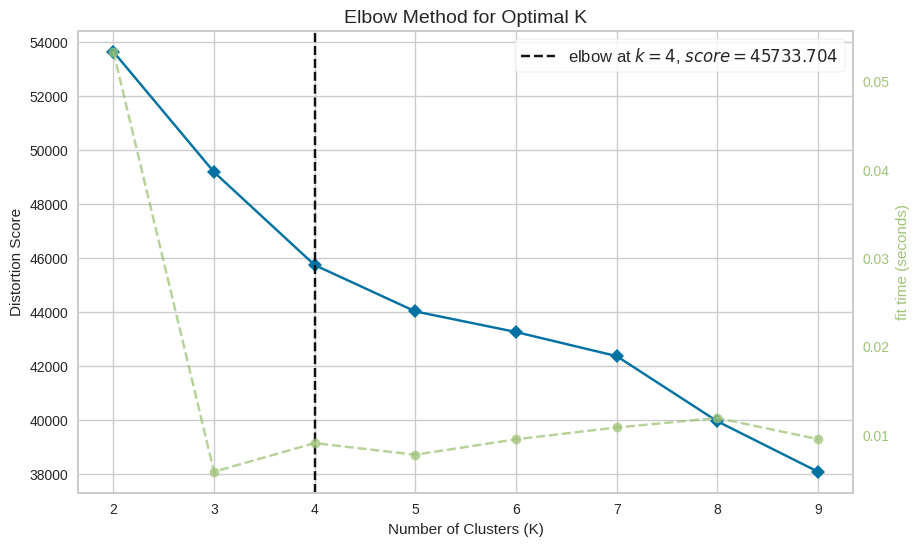

np.int64(4)

In [20]:
plot_elbow_curve(df, KMeans(init='k-means++', n_init='auto', random_state=42))

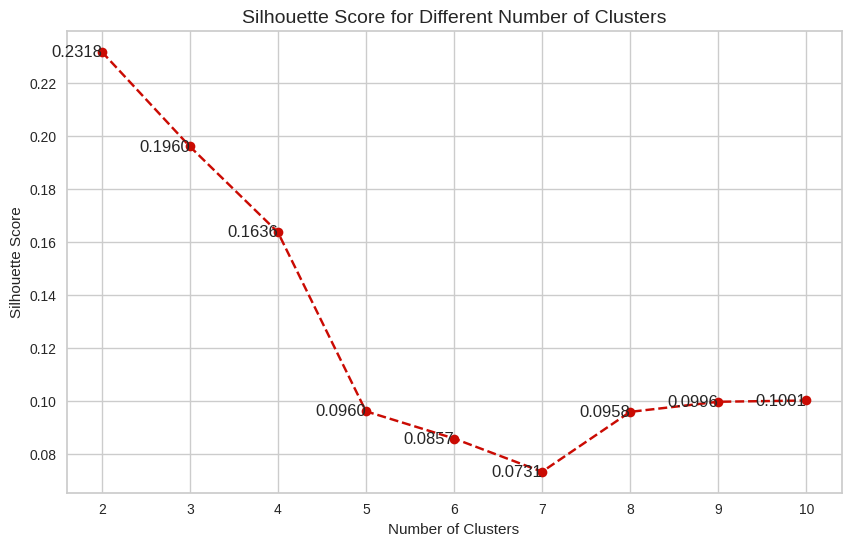

(2,
 [np.float64(0.23182889586217567),
  np.float64(0.19603042220217418),
  np.float64(0.16361403762781082),
  np.float64(0.09596547874098721),
  np.float64(0.08569063602278292),
  np.float64(0.07314223610025478),
  np.float64(0.09575799626622726),
  np.float64(0.09957605957245269),
  np.float64(0.10005331762605577)])

In [21]:
plot_silhouette_scores(df, KMeans(init='k-means++', n_init='auto', random_state=42))

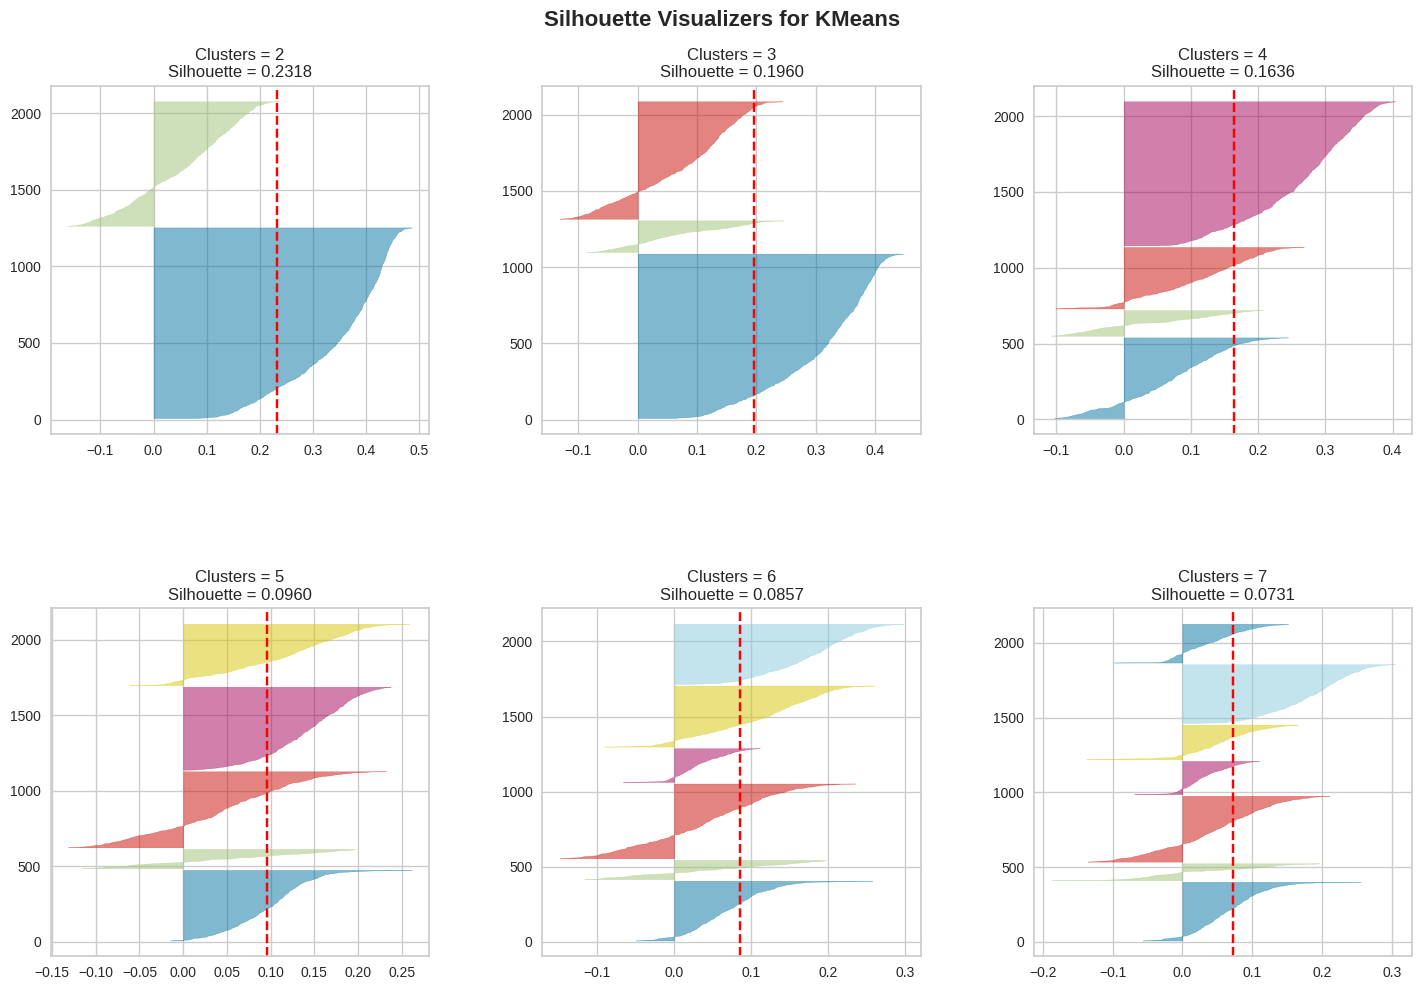

In [22]:
plot_silhouette_subplots(df, model_class=KMeans,
                         cluster_range=range(2, 8), init='k-means++',
                         n_init='auto', random_state=42)

In [23]:
from sklearn.cluster import KMeans

results_df = evaluate_clusters(
    X=df,
    model_class=KMeans,
    cluster_range=range(2, 8),
    init='k-means++',
    n_init='auto',
    random_state=42
)

results_df.style.background_gradient(cmap="Blues", subset=results_df.columns[1::])

,Clusters,Davies-Bouldin Score,Calinski-Harabasz Score,Silhouette Score
0,2,1.857235,546.788703,0.231829
1,3,2.067841,391.325435,0.196030
2,4,2.184095,332.055085,0.163614
3,5,2.387691,278.675623,0.095965
4,6,2.397020,234.019019,0.085691
5,7,2.729556,206.233785,0.073142


* Across all metrics, 2 clusters consistently show the best performance:
    - Lowest DB (best separation/compactness)
    - Highest CH (best between/within cluster ratio)
    - Highest Silhouette (points closer to their own cluster than others)
* Adding more clusters deteriorates clustering quality, likely overfitting or splitting naturally cohesive clusters.

* Consider trade-offs (Top 3)
    - 2 clusters: Best overall — highest Silhouette (0.232), lowest DB (1.857), highest CH (546.79). Simple and compact, may be too coarse.
    - 3 clusters: Slightly lower Silhouette (0.196) and higher DB (2.068). Adds granularity but cluster quality slightly worse.
    - 4 clusters: Silhouette drops further (0.164), DB increases (2.184). More clusters, but cohesion and separation weaken.

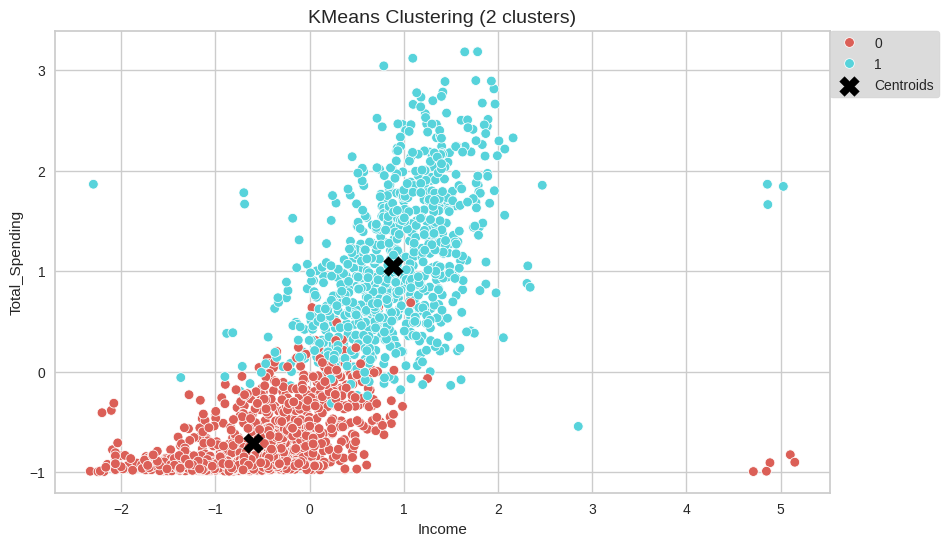

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = kmeans.fit_predict(df)

df_kmeans = df.copy()
df_kmeans['Cluster'] = labels

fig, ax = plt.subplots(figsize=(10, 6))
plot_clusters(
    ax=ax,
    data=df_kmeans,
    x='Income',
    y='Total_Spending',
    title='KMeans Clustering (2 clusters)',
    cluster_col='Cluster',
    centroids=kmeans.cluster_centers_
)
plt.show()

In [25]:
df_temp = df_org.copy()
df_temp['Cluster'] = df_kmeans['Cluster']

df_temp[['Cluster', 'Total_Spending', 'Income', 'Total_Num_Purchases', 'Age', 'Customer_Tenure']].groupby('Cluster').agg(['count', 'mean', 'median'])

Total_Spending                   Income                      \
                 count     mean   median  count      mean    median   
Cluster                                                               
0                 1228   179.87    90.00   1228 39,158.95 38,577.00   
1                  830 1,237.06 1,169.00    830 71,218.89 71,277.00   

        Total_Num_Purchases                Age              Customer_Tenure  \
                      count  mean median count  mean median           count   
Cluster                                                                       
0                      1228 10.25   9.00  1228 43.80  42.00            1228   
1                       830 21.70  22.00   830 47.27  47.00             830   

                       
          mean median  
Cluster                
0       333.78 326.00  
1       380.11 403.00

### **2. KMeans with PCA**

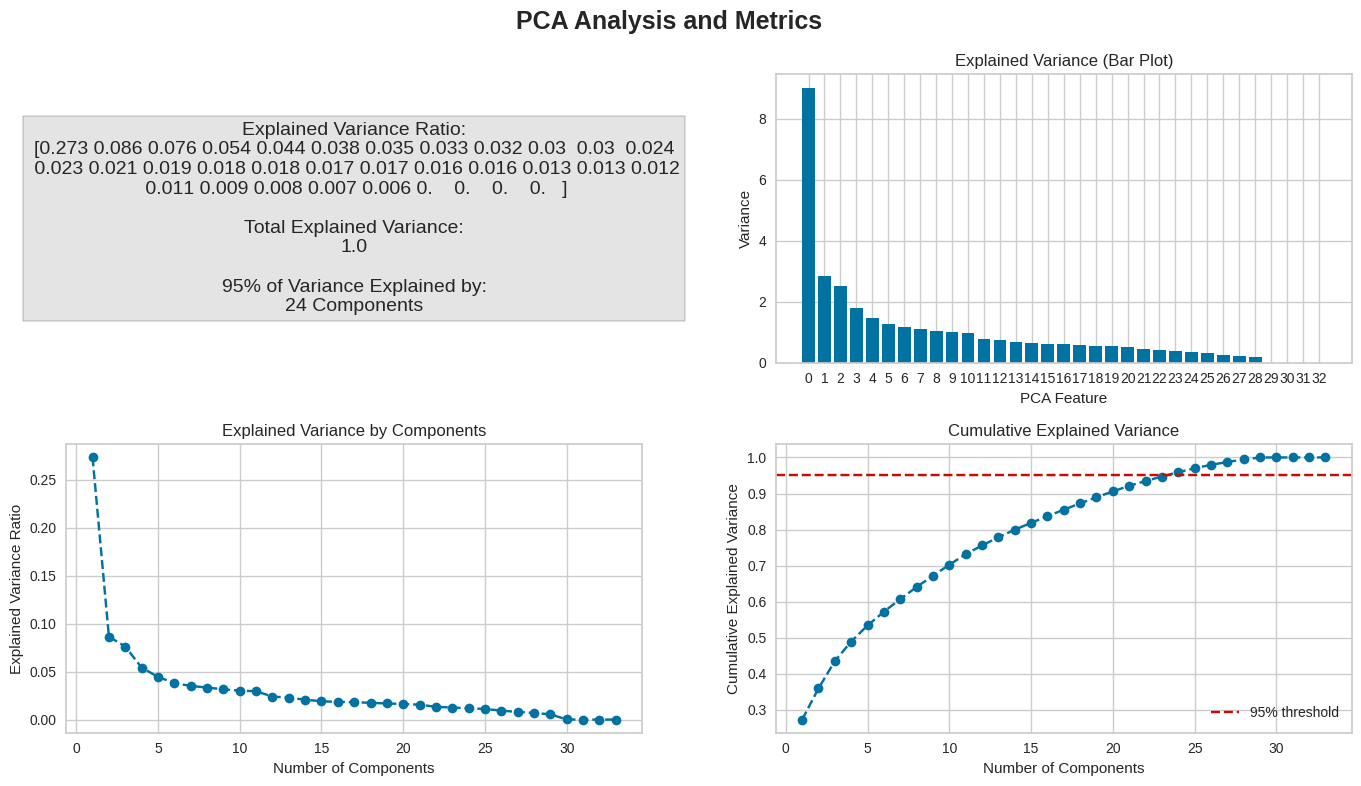

In [26]:
from sklearn.decomposition import PCA



def plot_pca_analysis(df, threshold=0.95):
    pca = PCA()
    pca.fit(df)

    explained_variance = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance)
    features = range(pca.n_components_)

    components_for_threshold = np.argmax(cumulative_variance >= threshold) + 1
    best_dimension = np.argmax(cumulative_variance >= threshold)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    axes[0, 0].axis('off')
    score_text = (f'Explained Variance Ratio:\n{np.round(explained_variance, 3)}\n\n'
                  f'Total Explained Variance:\n{round(sum(explained_variance), 3)}\n\n'
                  f'{int(threshold * 100)}% of Variance Explained by:\n'
                  f'{components_for_threshold} Components')
    axes[0, 0].text(0.5, 0.5, score_text, fontsize=14, ha='center', va='center',
                    bbox=dict(facecolor='lightgray', alpha=0.6))

    axes[0, 1].bar(features, pca.explained_variance_)
    axes[0, 1].set_xlabel('PCA Feature')
    axes[0, 1].set_ylabel('Variance')
    axes[0, 1].set_title('Explained Variance (Bar Plot)')
    axes[0, 1].set_xticks(features)

    axes[1, 0].plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
    axes[1, 0].set_xlabel('Number of Components')
    axes[1, 0].set_ylabel('Explained Variance Ratio')
    axes[1, 0].set_title('Explained Variance by Components')
    axes[1, 0].grid(True)

    axes[1, 1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
    axes[1, 1].axhline(y=threshold, color='r', linestyle='--', label=f'{int(threshold * 100)}% threshold')
    axes[1, 1].set_xlabel('Number of Components')
    axes[1, 1].set_ylabel('Cumulative Explained Variance')
    axes[1, 1].set_title('Cumulative Explained Variance')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.suptitle('PCA Analysis and Metrics', fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()


plot_pca_analysis(df, threshold=0.95)

In [27]:
# Fit PCA first (X is your scaled data / features)
pca = PCA().fit(df)

# Cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Targets
thresholds = [0.70, 0.80, 0.90, 0.95]

for thresh in thresholds:
    # number of components needed to reach threshold
    n_components = np.argmax(cumulative_variance >= thresh) + 1
    print(f"{int(thresh*100)}% = {n_components} components")


70% = 10 components
80% = 15 components
90% = 20 components
95% = 24 components


In [28]:
pca = PCA(n_components=20)
pca.fit(df)

# Transform
pca_array = pca.transform(df)

# Convert to DataFrame for clarity
pca_df = pd.DataFrame(
    pca_array,
    columns=[f'PC{i+1}' for i in range(20)]
)

pca_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
0,4.22,1.23,-1.05,2.34,0.47,-0.17,-0.17,1.29,0.19,0.48,0.74,-1.01,3.23,0.59,-0.41,-0.60,-0.33,0.51,0.37,0.46
1,-3.06,-0.48,-0.07,-2.10,-0.30,1.23,0.46,-0.40,0.69,0.48,-0.36,-0.20,0.82,-0.14,-0.14,0.09,-0.45,-0.44,-0.12,0.28
2,2.07,-0.04,-1.66,0.04,-0.25,-1.01,-0.21,0.00,0.36,0.81,0.35,-0.07,-0.59,-0.01,1.00,-0.08,-0.27,-1.67,-0.60,0.36
3,-2.96,-1.58,-0.43,-0.10,-0.18,0.31,-1.11,-0.26,-0.39,1.20,1.36,0.02,-0.04,0.59,-0.16,0.21,-0.25,-0.54,-0.29,0.18
4,-0.63,0.57,-0.48,-0.53,0.28,0.98,-0.95,0.15,-2.08,-0.34,1.75,0.54,0.28,0.41,0.47,-0.23,0.58,1.53,0.86,0.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2053,-0.67,-0.43,-0.40,0.15,-1.14,-0.21,1.85,-1.63,0.09,0.86,0.33,1.11,-1.62,-0.65,0.12,-0.09,-0.80,-0.56,0.37,-0.19
2054,2.27,2.30,-0.93,1.22,0.32,0.19,-0.89,0.62,0.50,-0.20,-1.75,-0.08,-0.11,0.46,-0.02,2.59,1.49,-0.43,0.42,-0.34
2055,1.97,-0.72,0.88,-1.23,1.03,-1.31,-3.30,-0.55,-1.72,-1.44,0.74,-0.65,-0.38,-0.93,-1.08,-1.50,1.06,0.43,1.47,-0.04
2056,1.96,0.87,-1.04,-1.98,-2.45,0.24,-0.00,-0.20,0.52,1.06,0.44,0.26,-0.17,-0.59,0.75,0.09,-0.25,-0.66,-0.21,-0.28


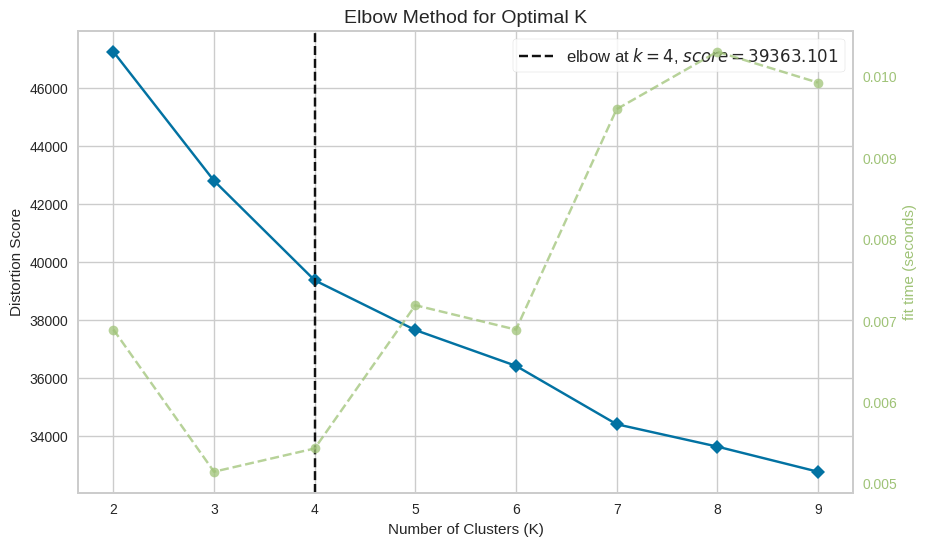

np.int64(4)

In [29]:
plot_elbow_curve(pca_df, KMeans(init='k-means++', n_init='auto', random_state=42))

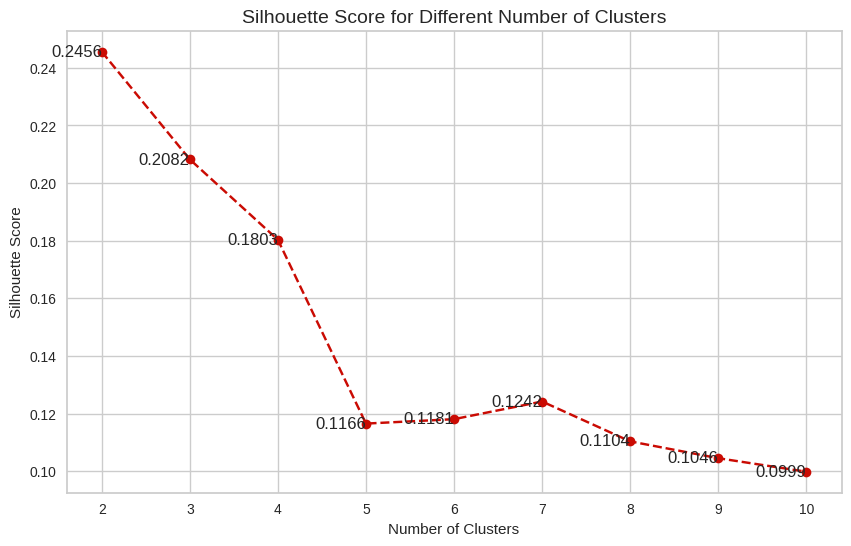

(2,
 [np.float64(0.24556150274208866),
  np.float64(0.20820647507048773),
  np.float64(0.1803266608944845),
  np.float64(0.11656402784024937),
  np.float64(0.11810406094327795),
  np.float64(0.12422685079113191),
  np.float64(0.11039396051857904),
  np.float64(0.1045589877875756),
  np.float64(0.09986914716562242)])

In [30]:
plot_silhouette_scores(pca_df, KMeans(init='k-means++', n_init='auto', random_state=42))

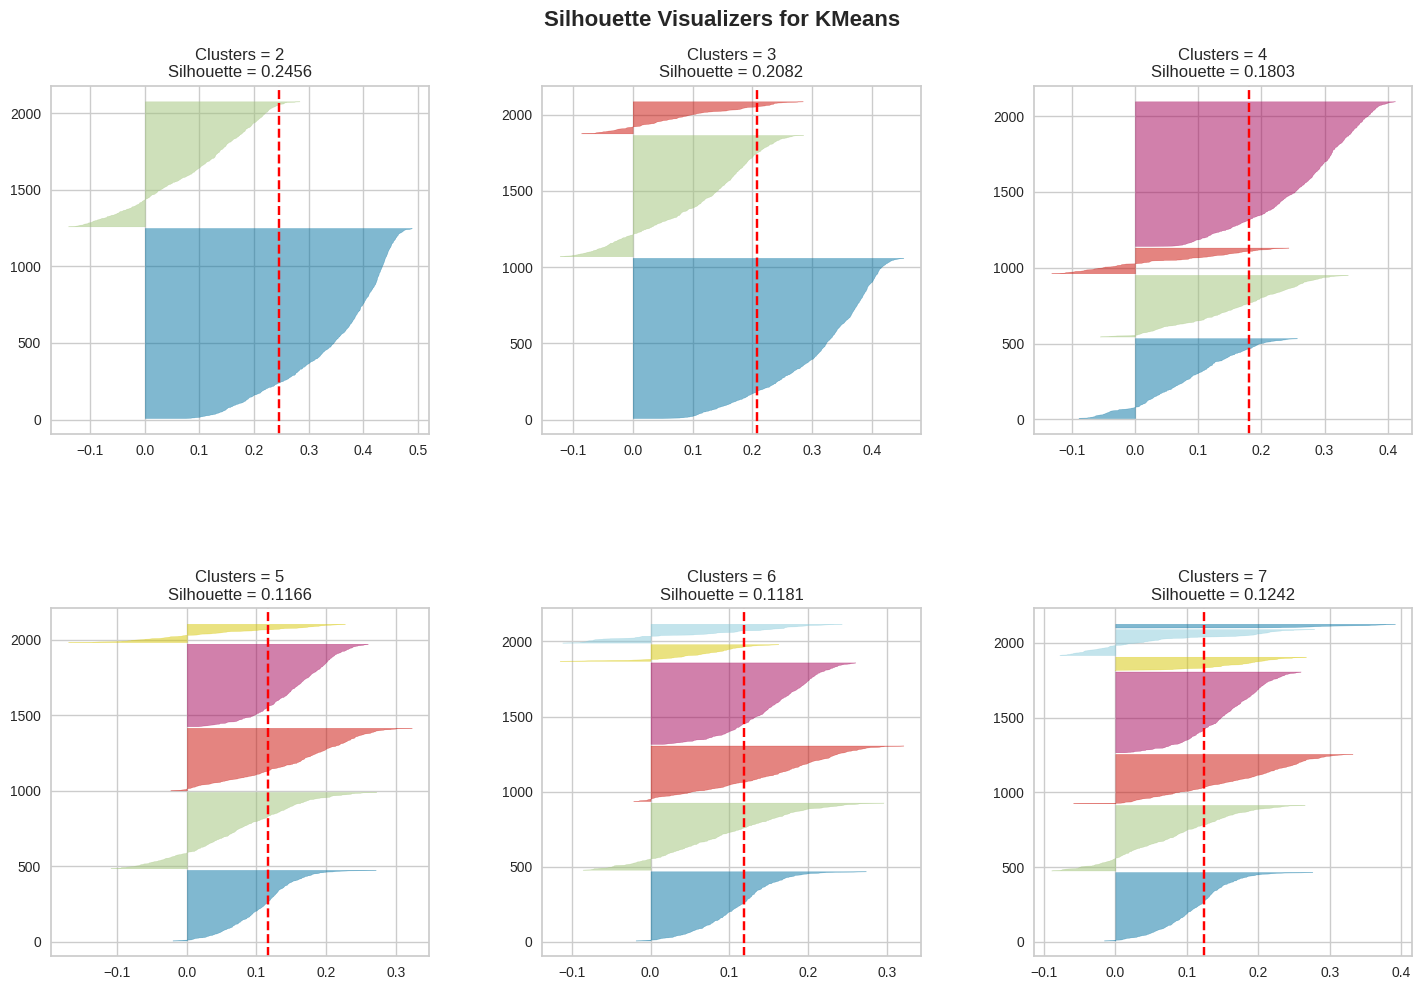

In [31]:
plot_silhouette_subplots(pca_df, model_class=KMeans,
                         cluster_range=range(2, 8), init='k-means++',
                         n_init='auto', random_state=42)

In [32]:
from sklearn.cluster import KMeans

results_df = evaluate_clusters(
    X=pca_df,
    model_class=KMeans,
    cluster_range=range(2, 8),
    init='k-means++',
    n_init='auto',
    random_state=42
)

results_df.style.background_gradient(cmap="Blues", subset=results_df.columns[1::])

,Clusters,Davies-Bouldin Score,Calinski-Harabasz Score,Silhouette Score
0,2,1.733267,620.217149,0.245562
1,3,1.903520,449.210290,0.208206
2,4,1.991476,385.236266,0.180327
3,5,2.196079,325.375041,0.116564
4,6,2.151832,282.960171,0.118104
5,7,2.016707,269.508800,0.124227


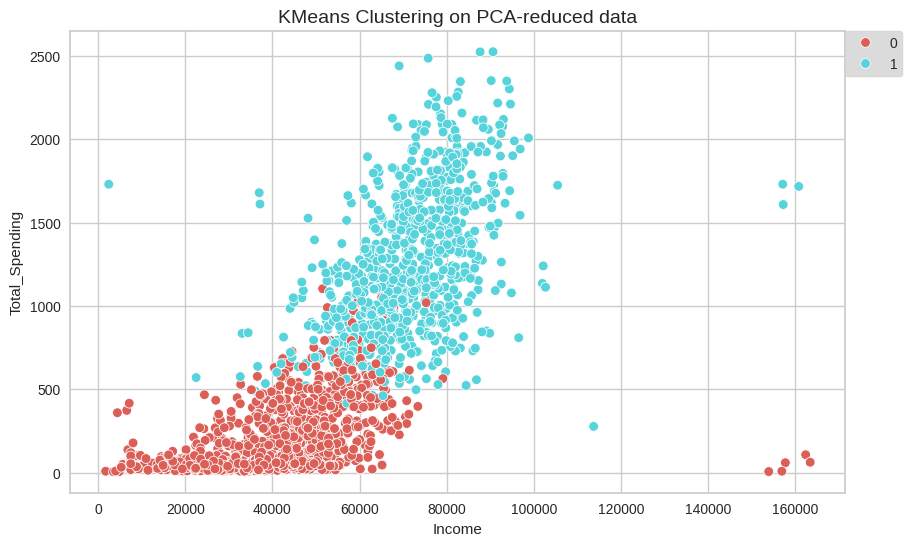

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = kmeans.fit_predict(pca_df)

df_kmeans_pca = df_org.copy()  # or original unscaled df if you prefer
df_kmeans_pca['Cluster'] = labels

fig, ax = plt.subplots(figsize=(10, 6))
plot_clusters(
    ax=ax,
    data=df_kmeans_pca,
    x='Income',
    y='Total_Spending',
    title='KMeans Clustering on PCA-reduced data',
    cluster_col='Cluster',
    centroids=None)
plt.show()

### **3. DBSCAN**

In [34]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import pandas as pd
import numpy as np

# NOTE: df must be already scaled before running this block

def dbscan_sweep(df, eps_values=None, min_samples_values=None):
    # Use provided ranges or default
    if eps_values is None:
        eps_values = np.arange(1.0, 6.0, 0.5)
    if min_samples_values is None:
        min_samples_values = np.arange(3, 10, 1)

    results = []

    for eps in eps_values:
        for min_samples in min_samples_values:
            model = DBSCAN(eps=eps, min_samples=min_samples)
            try:
                labels = model.fit_predict(df)

                unique_labels = set(labels)
                n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
                outlier_ratio = np.sum(labels == -1) / len(labels)

                if n_clusters <= 0:
                    silhouette = np.nan
                    db_index = np.nan
                    ch_score = np.nan
                else:
                    silhouette = silhouette_score(df, labels)
                    db_index = davies_bouldin_score(df, labels)
                    ch_score = calinski_harabasz_score(df, labels)

                results.append({
                    'eps': eps,
                    'min_samples': min_samples,
                    'Num_Clusters': n_clusters,
                    'Outlier_Ratio': outlier_ratio,
                    'Silhouette': silhouette,
                    'Davies-Bouldin': db_index,
                    'Calinski-Harabasz': ch_score
                })

            except Exception as e:
                print(f"Failed for eps={eps}, min_samples={min_samples}: {e}")

    results_df = pd.DataFrame(results)
    return results_df


# ---- Run sweep ----
eps_values = np.arange(1.0, 6.0, 0.5)
min_samples_values = np.arange(3, 10, 1)
dbscan_results = dbscan_sweep(df, eps_values=eps_values, min_samples_values=min_samples_values)
dbscan_results.style.background_gradient(cmap="Blues", subset=dbscan_results.columns[4::])


,eps,min_samples,Num_Clusters,Outlier_Ratio,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,1.000000,3,3,0.995141,-0.211725,1.418040,1.859612
1,1.000000,4,1,0.998056,-0.156050,1.401715,2.244441
2,1.000000,5,0,1.000000,nan,nan,nan
3,1.000000,6,0,1.000000,nan,nan,nan
4,1.000000,7,0,1.000000,nan,nan,nan
5,1.000000,8,0,1.000000,nan,nan,nan
6,1.000000,9,0,1.000000,nan,nan,nan
7,1.500000,3,31,0.907191,-0.246583,1.488444,3.550321
8,1.500000,4,18,0.935860,-0.224758,1.541204,4.067744
9,1.500000,5,12,0.955296,-0.223698,1.551274,4.151247


In [35]:
dbscan = DBSCAN(eps = 1.0, min_samples = 3).fit(df)



df_dbscan = df_org.copy()



df_dbscan['cluster'] = dbscan.labels_
df_dbscan['cluster'].value_counts()

,count
cluster,
-1,2048
0,4
2,3
1,3


In [36]:
# centroids = df_dbscan.groupby('cluster').mean().values

# fig, ax = plt.subplots(figsize=(10, 6))
# plot_clusters(
#     ax=ax,
#     data=df_dbscan,
#     x='Income',
#     y='Total_Spending',
#     title='DBSCAN',
#     cluster_col='cluster',
#     centroids=centroids
# )
# plt.show()

### **4. AgglomerativeClustering**

In [37]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import pandas as pd
import matplotlib.pyplot as plt

# NOTE: df must be already scaled before running this block

def agglo_sweep(df, k_min=2, k_max=10, linkages=['ward','complete','average']):
    results = []

    for linkage in linkages:
        for k in range(k_min, k_max+1):
            model = AgglomerativeClustering(n_clusters=k, linkage=linkage)
            try:
                labels = model.fit_predict(df)

                # Compute metrics
                silhouette = silhouette_score(df, labels)
                db_index = davies_bouldin_score(df, labels)
                ch_score = calinski_harabasz_score(df, labels)

                results.append({
                    'Linkage': linkage,
                    'k': k,
                    'Silhouette': silhouette,
                    'Davies-Bouldin': db_index,
                    'Calinski-Harabasz': ch_score
                })

            except Exception as e:
                print(f"Failed for linkage={linkage}, k={k}: {e}")

    results_df = pd.DataFrame(results)
    return results_df


# ---- Run sweep ----
agglo_results = agglo_sweep(df)
agglo_results.style.background_gradient(cmap="Blues", subset=agglo_results.columns[2::])

,Linkage,k,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,ward,2,0.248284,1.930714,390.781449
1,ward,3,0.110352,2.351621,320.864331
2,ward,4,0.107941,2.283153,265.599949
3,ward,5,0.116063,2.271778,234.096429
4,ward,6,0.124227,2.092398,215.988083
5,ward,7,0.135112,1.840366,205.233271
6,ward,8,0.111137,2.264347,191.430667
7,ward,9,0.099686,2.182311,180.772733
8,ward,10,0.090461,2.085842,170.817380
9,complete,2,0.447364,1.049757,99.159875


In [38]:
Agg1 = AgglomerativeClustering(n_clusters=2, linkage='complete')

In [39]:
df_aggl = df_org.copy()

y_agg = Agg1.fit_predict(df)
df_aggl['cluster'] = y_agg

### **Model Comparison**

Although the Agglomerative model achieved the best internal metrics (Silhouette = 0.45, Davies–Bouldin = 1.05), its clustering result was highly imbalanced, forming one large cluster (2,032 samples) and one small cluster (26 samples). This indicates that the algorithm mainly grouped most observations into a single cluster, failing to capture meaningful structure. Therefore, **K-Means** was selected as the most suitable model, as it provided more balanced and interpretable clusters.

In [40]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import pandas as pd
import numpy as np

# List of models with their data
models = [
    ('KMeans', kmeans, df),
    ('KMeans_PCA', kmeans, pca_df),
    ('Agglomerative', Agg1, df),
    ('DBSCAN', dbscan, df)
]

results = []

for name, model, data in models:
    try:
        labels = model.fit_predict(data)

        if name == 'DBSCAN':
            unique_labels = set(labels)
            n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
            outlier_ratio = np.sum(labels == -1) / len(labels)
            if n_clusters <= 0:
                silhouette = np.nan
                db_index = np.nan
                ch_score = np.nan
            else:
                silhouette = silhouette_score(data, labels)
                db_index = davies_bouldin_score(data, labels)
                ch_score = calinski_harabasz_score(data, labels)
        else:
            n_clusters = len(set(labels))
            outlier_ratio = 0.0
            silhouette = silhouette_score(data, labels)
            db_index = davies_bouldin_score(data, labels)
            ch_score = calinski_harabasz_score(data, labels)

        results.append({
            'Model': name,
            'Num_Clusters': n_clusters,
            'Outlier_Ratio': outlier_ratio,
            'Silhouette': silhouette,
            'Davies-Bouldin': db_index,
            'Calinski-Harabasz': ch_score
        })
    except Exception as e:
        print(f"{name} failed: {e}")

# Convert to DataFrame
comparison_df = pd.DataFrame(results)
comparison_df


,Model,Num_Clusters,Outlier_Ratio,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,KMeans,2,0.00,0.23,1.86,546.81
1,KMeans_PCA,2,0.00,0.25,1.73,620.22
2,Agglomerative,2,0.00,0.45,1.05,99.16
3,DBSCAN,3,1.00,-0.21,1.42,1.86


### **Profiling Customers**

In [41]:
df_kmeans_pca.Cluster.value_counts()

,count
Cluster,
0,1241
1,817


In [42]:
cat_cols = ['Education', 'Marital_Status', 'Income_Cat', 'Total_Kids']
num_cols = ['Age', 'Income', 'Total_Spending', 'Total_Num_Purchases']

In [43]:
num_profile = df_kmeans_pca.groupby('Cluster')[num_cols].agg(['mean', 'median', 'std', 'min', 'max'])
num_profile


Age                              Income                      \
         mean median   std   min    max      mean    median       std   
Cluster                                                                 
0       43.92  42.00 11.43 18.00 110.00 39,386.00 38,680.00 15,977.59   
1       47.15  47.00 12.37 19.00 110.00 71,384.15 71,488.00 13,145.75   

                            Total_Spending                                  \
             min        max           mean   median    std    min      max   
Cluster                                                                      
0       1,730.00 163,433.00         186.29    91.00 195.42   5.00 1,103.00   
1       2,447.00 160,803.00       1,244.14 1,178.00 427.14 277.00 2,525.00   

        Total_Num_Purchases                         
                       mean median  std  min   max  
Cluster                                             
0                     10.35   9.00 5.59 0.00 32.00  
1                     21.73  22.00 4.74 1.00 44.00

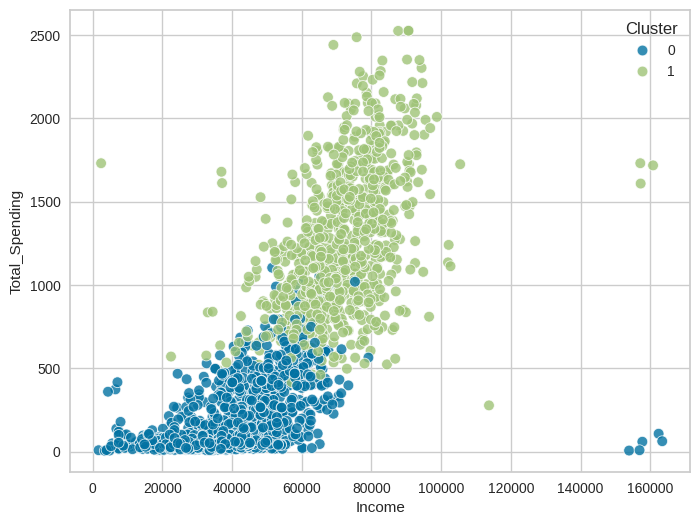

In [56]:

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_kmeans_pca,
    x='Income',
    y='Total_Spending',
    hue='Cluster',
    s=60,
    alpha=0.8
)
plt.legend(title='Cluster')
plt.show()


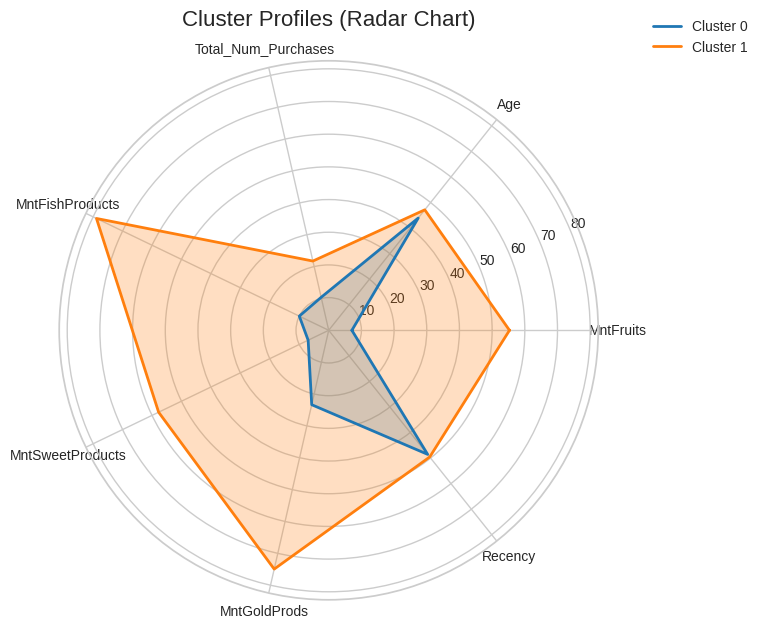

In [44]:
# Features
features_radar = ['MntFruits', 'Age', 'Total_Num_Purchases',
                  'MntFishProducts', 'MntSweetProducts',
                  'MntGoldProds', 'Recency']
# Group by cluster
df_grouped = df_kmeans_pca.groupby('Cluster')[features_radar].mean()

# No scaling – use raw values
df_normalized = df_grouped.copy()  # just keep the raw values

# Radar chart setup
labels = df_normalized.columns.tolist()
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False)
angles = np.concatenate((angles, [angles[0]]))  # close the loop

# Create figure
fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))

# Colors
colors = plt.cm.tab10(np.arange(len(df_normalized)))

# Plot each cluster
for i, cluster in enumerate(df_normalized.index):
    values = df_normalized.loc[cluster].values
    values = np.concatenate((values, [values[0]]))  # close the loop
    ax.plot(angles, values, color=colors[i], linewidth=2, label=f'Cluster {cluster}')
    ax.fill(angles, values, color=colors[i], alpha=0.25)

# Set the labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

# Title and legend
plt.title('Cluster Profiles (Radar Chart)', size=16, y=1.05)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()


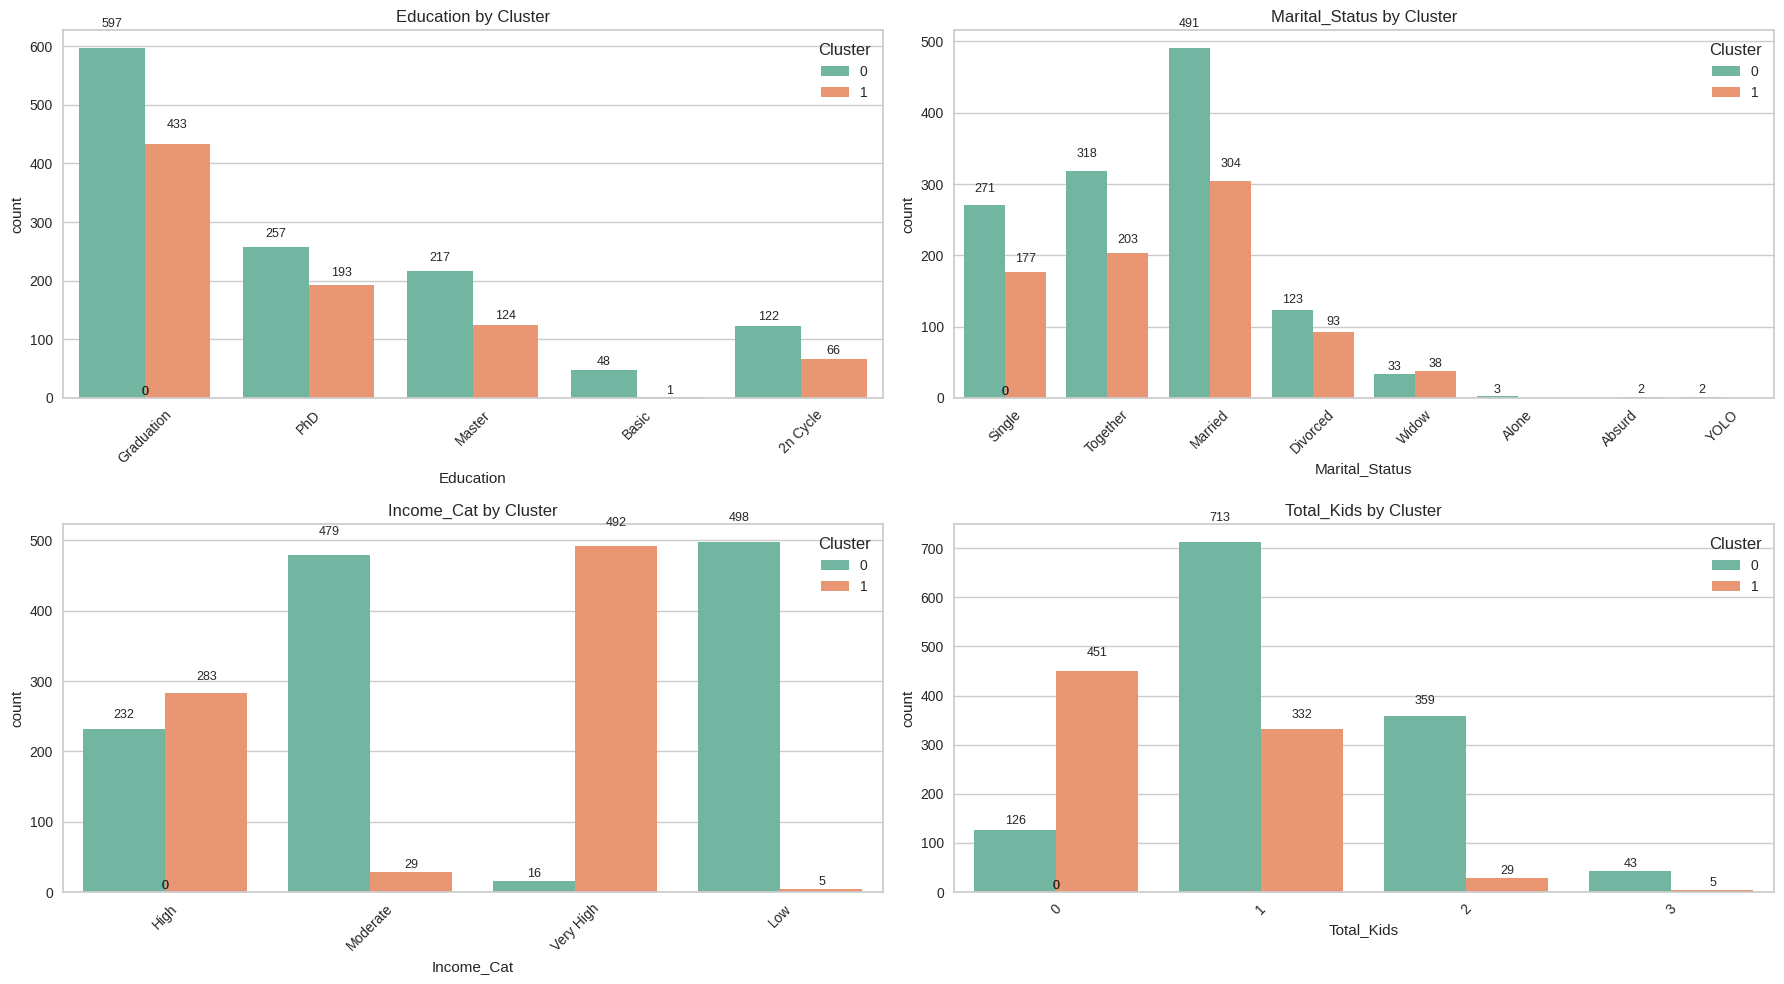

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_cat_bar_grid_hue(df, cat_cols, hue_col):
    """
    Create a n x 2 grid of bar plots for categorical columns in a DataFrame
    with a hue for clusters or groups, showing value counts.

    Parameters:
    df : pd.DataFrame
        The dataframe containing the categorical columns
    cat_cols : list
        List of categorical column names to plot
    hue_col : str
        Column name to use as hue (clusters/groups)
    """
    n = len(cat_cols)
    nrows = (n + 1) // 2  # number of rows for a 2-column grid
    fig, axes = plt.subplots(nrows, 2, figsize=(18, nrows*5))
    axes = axes.flatten()

    for i, col in enumerate(cat_cols):
        # Use Seaborn countplot with hue
        sns.countplot(data=df, x=col, hue=hue_col, ax=axes[i], palette='Set2')

        # Add value labels on top of each bar
        for p in axes[i].patches:
            height = p.get_height()
            axes[i].text(p.get_x() + p.get_width()/2, height + 0.05*height, f'{int(height)}',
                         ha='center', va='bottom', fontsize=9)

        axes[i].set_title(f'{col} by {hue_col}')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].legend(title=hue_col, loc='upper right')

    # Hide any unused subplots
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

plot_cat_bar_grid_hue(df_kmeans_pca, cat_cols, hue_col="Cluster")


Cluster Summary
| Cluster | Size | Customer Type                                                                              |
| ------- | ---- | ------------------------------------------------------------------------------------------ |
| **0**   | 1241 | **Mass / Regular Customers** (Low-Moderate income, average spending)                       |
| **1**   | 817  | **Premium / High-Value Customers** (Very high income, extremely high spending & purchases) |


🔎 Profile of Cluster 0 — “Regular / Budget-Conscious Families”

* Age ~ 44 on average
* Income: ~ 39k (median ~ 38.6k)
* Income Category: majority Low and Moderate
* Spending: low (~186 total spending on average)
* Purchases: low (~10 on average)
* Education: mostly Graduation, followed by PhD and Master, but these still correlate with moderate income
* Family Structure: mostly 1 or 2 kids
* Likely Persona: Middle-aged, mid-income, family-oriented, controlled spending habits, price-sensitive.

These are likely the average core customers, but not high contributors to revenue individually.

---

🔎 Profile of Cluster 1 — “High-Spending, High-Income Elite”

* Age ~ 47 (slightly older)
* Income: ~ 71k (almost double cluster 0)
* Income Category: Very High (dominant), High
* Spending: ~ 1244 (massively higher than cluster 0)
* Purchases: ~ 22 purchases (more than 2x cluster 0)
* Kids: Many have 0 kids
* Marital Status: Mostly married/together but often child-free or fewer dependents
* Likely Persona: High-income professionals / executives, financially comfortable, higher discretionary spending, low family constraints → more lifestyle/luxury spending.

This cluster is large (817 people) and they are your most valuable segment, accounting for a disproportionately large share of spending.

The clusters are not just based on quantity, but on value.

* Cluster 1 contains ~40% of customers (817 out of 2,058 total)
* Their spending is still roughly 6–7x higher than Cluster 0.
* These are high-value customers, representing a major revenue segment rather than just a small VIP niche.

Sociodemographic Structure is Logical

* High spenders = mostly no kids, more disposable income
* Higher education level (PhD, Master) → higher earning capacity
* Likely more focused on lifestyle, travel, premium products

Strategic Value
| Cluster   | Strategy                                                                |
| --------- | ----------------------------------------------------------------------- |
| Cluster 0 | Price promos, volume discounts, loyalty campaigns, bundles for families |
| Cluster 1 | VIP programs, premium offerings, exclusive products, luxury experiences |
